In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<unknown>:38: SyntaxWarning: invalid escape sequence '\.'


In [94]:
titanic_train_df = pd.read_csv('../data/train.csv')
titanic_test_df = pd.read_csv('../data/test.csv')

titanic_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [95]:
from sklearn.model_selection import train_test_split

X = titanic_train_df.drop(columns="Survived")
y = titanic_train_df["Survived"].astype("int")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [96]:
from src.transformers import FeatureEngineeringTransformer
from src.transformers import EncoderTransformer
from src.transformers import MissingValueTransformer
from src.transformers import FeatureSelectorTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

model = XGBClassifier(tree_method='hist', n_estimators=1000, enable_categorical=True, learning_rate=0.05, n_jobs=4, random_state=42)

preprocessor = Pipeline([
    ("missing", MissingValueTransformer()),
    ("features", FeatureEngineeringTransformer()),
    ("encoder", EncoderTransformer()),
    ("selector", FeatureSelectorTransformer()),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


In [97]:
X_processed = preprocessor.fit_transform(X_train, y_train)

X_processed.info()

<ArrowStringArray>
[      'Mr',      'Mrs',      'Col',     'Miss',      'Rev',    'Major',
   'Master',       'Dr',     'Mlle',     'Lady',      'Sir',       'Ms',
 'Jonkheer',      'Don']
Length: 14, dtype: str
<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pclass         712 non-null    int64  
 1   Sex            712 non-null    int64  
 2   AgeFilled      712 non-null    float64
 3   SibSp          712 non-null    int64  
 4   Parch          712 non-null    int64  
 5   Fare           712 non-null    float64
 6   Embarked       712 non-null    int64  
 7   Title          712 non-null    int64  
 8   IsAlone        712 non-null    int64  
 9   FamilySize     712 non-null    int64  
 10  CabinCat       712 non-null    int64  
 11  FarePerPerson  712 non-null    float64
 12  IsChild        712 non-null    int64  
dtypes: float64(3), int64(10)
memory

In [98]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=4, error_score="raise")

print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean cross-validation accuracy: {np.mean(scores)}")

Cross-validation accuracy scores: [0.82517483 0.78321678 0.84507042 0.82394366 0.83098592]
Mean cross-validation accuracy: 0.8216783216783217


In [99]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform, uniform

param_grid = {
    'model__max_depth': [1, 2, 3, 5, 6, 10, 15],
    'model__min_child_weight': [1, 2, 3, 5, 6, 10],
    'model__gamma': [0, 0.1, 0.5, 1, 1.5, 2, 3, 5, 6, 10],
    'model__learning_rate': [0.005, 0.05, 0.1, 0.5],
    'model__subsample': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'model__colsample_bytree': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'model__reg_alpha': [0, 0.05, 0.1, 0.5, 1, 2, 3, 5, 8, 10],
    'model__reg_lambda': [1, 1.5, 2, 3, 5, 6, 10],
    'model__n_estimators': [100, 200, 300, 400, 500, 600],
    'model__max_delta_step': [1, 2, 3, 5, 6, 10],
    'model__tree_method': ['approx']
}

grid = RandomizedSearchCV(pipeline, n_jobs=4, param_distributions=param_grid, scoring='accuracy', cv=5, n_iter=50, random_state=42, error_score='raise')
grid.fit(X_train, y_train)

<ArrowStringArray>
[      'Mr',      'Mrs',      'Col',     'Miss',      'Rev',    'Major',
   'Master',       'Dr',     'Mlle',     'Lady',      'Sir',       'Ms',
 'Jonkheer',      'Don']
Length: 14, dtype: str


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.3, 0.4, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.005, 0.05, ...], 'model__max_delta_step': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given th

In [100]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

<ArrowStringArray>
[      'Mr',      'Mrs',      'Col',     'Miss',      'Rev',    'Major',
   'Master',       'Dr',     'Mlle',     'Lady',      'Sir',       'Ms',
 'Jonkheer',      'Don']
Length: 14, dtype: str


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('missing', ...), ('features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbo

In [101]:
from sklearn.metrics import classification_report

pred = best_model.predict(X_test)

print(classification_report(y_test, pred, target_names=['Not Survived', 'Survived']))

<ArrowStringArray>
['Mr', 'Miss', 'Mrs', 'Major', 'Mme', 'Master', 'Capt', 'Countess', 'Dr',
 'Rev']
Length: 10, dtype: str
              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       110
    Survived       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [102]:
best_model.score(X_test, y_test)

<ArrowStringArray>
['Mr', 'Miss', 'Mrs', 'Major', 'Mme', 'Master', 'Capt', 'Countess', 'Dr',
 'Rev']
Length: 10, dtype: str


0.8156424581005587

<Axes: >

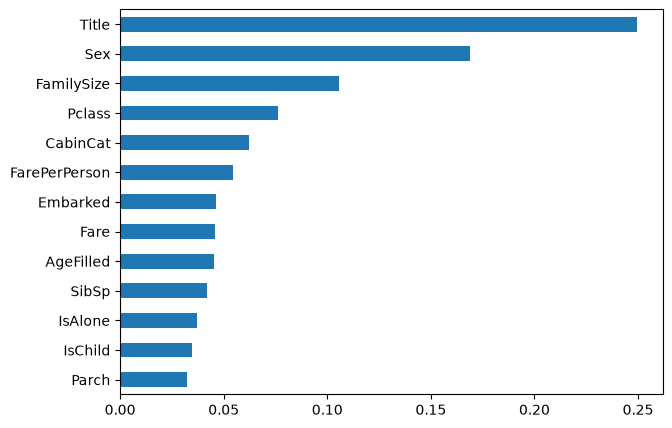

In [103]:
xgb = best_model.named_steps["model"]
feature_names = X_processed.columns
f_imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values() 
fig,ax=plt.subplots(figsize=(7,5))
f_imp.plot.barh(ax=ax)

In [104]:
pred_df = titanic_test_df
final_pred = best_model.predict(pred_df)

final_pred_doc = pd.DataFrame ({
    'PassengerId': titanic_test_df['PassengerId'],
    'Survived': final_pred
})

final_pred_doc.to_csv('../final_pred_doc_pipeline.csv', index=False)
final_pred_doc

<ArrowStringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona']
Length: 9, dtype: str


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [105]:
import joblib

joblib.dump(best_model, "../models/model.pkl")

['../models/model.pkl']